## Steps to Work with BigQuery Data in Python on Mac/PC

### Install Required Python Libraries
1. pip install google-cloud-bigquery pandas db-dtypes
2. brew install --cask google-cloud-sdk
3. initialize: gcloud init
4. Login with your Google account.


### Authenticate Python with BigQuery
1. Run: gcloud auth application-default login
2. This creates credentials so Python can access BigQuery.


### Import Libraries in Python

In [65]:
from google.cloud import bigquery
import pandas as pd

### Create BigQuery Client and Convert Result to Pandas DataFrame

In [14]:
def get_table(table):
    return bigquery.Client(project="peronal-489013") \  # create a BigQuery client connected to project
    .list_rows(f"Athelete_Project.{table}") \           # read rows from dataset and table name passed in 'table'
    .to_dataframe()                                     # convert the BigQuery result into a pandas DataFrame

#### import the table from bigquery available in dataframe

In [40]:
df1 = get_table("athlete_events") 
df2 = table("NOC_Regions")

## Work with df Using Pandas or with other library 

In [21]:
df1.head()

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
0,107506,Hermann Schreiber,M,26,NA,NA,Switzerland,SUI,1936 Summer,1936,Summer,Berlin,Aeronautics,Aeronautics Mixed Aeronautics,Gold
1,23691,"Heinz-Rudolf ""Rudi"" Cranz",M,17,NA,NA,Germany,GER,1936 Winter,1936,Winter,Garmisch-Partenkirchen,Alpine Skiing,Alpine Skiing Men's Combined,NA
2,65820,Maurice Lafforgue,M,20,NA,NA,France,FRA,1936 Winter,1936,Winter,Garmisch-Partenkirchen,Alpine Skiing,Alpine Skiing Men's Combined,NA
3,24115,Imre Csk,M,23,NA,NA,Hungary,HUN,1936 Winter,1936,Winter,Garmisch-Partenkirchen,Alpine Skiing,Alpine Skiing Men's Combined,NA
4,117378,Lszl Szalay,M,21,NA,NA,Hungary,HUN,1936 Winter,1936,Winter,Garmisch-Partenkirchen,Alpine Skiing,Alpine Skiing Men's Combined,NA


In [24]:
df2.head()

,NOC,region,notes
0,AFG,Afghanistan,None
1,ALB,Albania,None
2,ALG,Algeria,None
3,ASA,American Samoa,None
4,AND,Andorra,None


#### Merge datasets to convert NOC codes into region names and prepare final dataset for analysis

In [41]:
df = df1.merge(df2, on="NOC", how="left")[
    ['ID','Name','Sex','Age','Height','Weight','Team','region','Games','Year','Season','City','Sport','Event','Medal']
    ]
df.head()

#### Check the dtypes

In [42]:
df.dtypes

ID         Int64
Name      object
Sex       object
Age       object
Height    object
Weight    object
Team      object
region    object
Games     object
Year       Int64
Season    object
City      object
Sport     object
Event     object
Medal     object
dtype: object

#### Convert the dtypes

In [43]:
df["Age"] = pd.to_numeric(df["Age"], errors='coerce').astype("Int64")
df["Height"] = pd.to_numeric(df["Height"], errors='coerce').astype("Int64")
df["Weight"] = pd.to_numeric(df["Weight"], errors='coerce').astype("float")
df.dtypes

ID          Int64
Name       object
Sex        object
Age         Int64
Height      Int64
Weight    float64
Team       object
region     object
Games      object
Year        Int64
Season     object
City       object
Sport      object
Event      object
Medal      object
dtype: object

### Lets Find and clean the data

In [44]:
df.head()

,ID,Name,Sex,Age,Height,Weight,Team,region,Games,Year,Season,City,Sport,Event,Medal
0,107506,Hermann Schreiber,M,26,<NA>,NaN,Switzerland,Switzerland,1936 Summer,1936,Summer,Berlin,Aeronautics,Aeronautics Mixed Aeronautics,Gold
1,23691,"Heinz-Rudolf ""Rudi"" Cranz",M,17,<NA>,NaN,Germany,Germany,1936 Winter,1936,Winter,Garmisch-Partenkirchen,Alpine Skiing,Alpine Skiing Men's Combined,NA
2,65820,Maurice Lafforgue,M,20,<NA>,NaN,France,France,1936 Winter,1936,Winter,Garmisch-Partenkirchen,Alpine Skiing,Alpine Skiing Men's Combined,NA
3,24115,Imre Csk,M,23,<NA>,NaN,Hungary,Hungary,1936 Winter,1936,Winter,Garmisch-Partenkirchen,Alpine Skiing,Alpine Skiing Men's Combined,NA
4,117378,Lszl Szalay,M,21,<NA>,NaN,Hungary,Hungary,1936 Winter,1936,Winter,Garmisch-Partenkirchen,Alpine Skiing,Alpine Skiing Men's Combined,NA


In [45]:
df[df.duplicated]

,ID,Name,Sex,Age,Height,Weight,Team,region,Games,Year,Season,City,Sport,Event,Medal
11223,44875,Alfrd (Arnold-) Hajs (Guttmann-),M,50,<NA>,NaN,Hungary,Hungary,1928 Summer,1928,Summer,Amsterdam,Art Competitions,"Art Competitions Mixed Architecture, Architect...",NA
11229,49866,Emil Paul Anton Hoppe,M,52,<NA>,NaN,Austria,Austria,1928 Summer,1928,Summer,Amsterdam,Art Competitions,"Art Competitions Mixed Architecture, Architect...",NA
11230,44875,Alfrd (Arnold-) Hajs (Guttmann-),M,50,<NA>,NaN,Hungary,Hungary,1928 Summer,1928,Summer,Amsterdam,Art Competitions,"Art Competitions Mixed Architecture, Architect...",NA
11231,61069,Charles Zeller Klauder,M,56,<NA>,NaN,United States,USA,1928 Summer,1928,Summer,Amsterdam,Art Competitions,"Art Competitions Mixed Architecture, Architect...",NA
11233,44875,Alfrd (Arnold-) Hajs (Guttmann-),M,50,<NA>,NaN,Hungary,Hungary,1928 Summer,1928,Summer,Amsterdam,Art Competitions,"Art Competitions Mixed Architecture, Architect...",NA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
194722,33564,William Edgar Exshaw,M,34,<NA>,NaN,Olle,UK,1900 Summer,1900,Summer,Paris,Sailing,Sailing Mixed 2-3 Ton,Gold
194725,116681,Henri Lon Victor Susse,M,55,<NA>,NaN,Favorite-1,France,1900 Summer,1900,Summer,Paris,Sailing,Sailing Mixed 2-3 Ton,Silver
194749,79412,Camille mile Gaston Michelet,M,32,<NA>,NaN,Turquoise-3,France,1900 Summer,1900,Summer,Paris,Sailing,Sailing Mixed 3-10 Ton,NA
194755,68922,Leroy,M,<NA>,<NA>,NaN,Mascaret-4,France,1900 Summer,1900,Summer,Paris,Sailing,Sailing Mixed 3-10 Ton,NA


In [47]:
df.isnull().sum()

ID            0
Name          0
Sex           0
Age        9474
Height    60171
Weight    62875
Team          0
region      349
Games         0
Year          0
Season        0
City          0
Sport         0
Event         0
Medal         0
dtype: int64

### Clean the data

In [48]:
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)
df.head()

,ID,Name,Sex,Age,Height,Weight,Team,region,Games,Year,Season,City,Sport,Event,Medal
38,133735,Karol Marian Zajc (-Sayons),M,22,175,74.0,Poland,Poland,1936 Winter,1936,Winter,Garmisch-Partenkirchen,Alpine Skiing,Alpine Skiing Men's Combined,NA
58,2792,mile Allais,M,23,168,68.0,France,France,1936 Winter,1936,Winter,Garmisch-Partenkirchen,Alpine Skiing,Alpine Skiing Men's Combined,Bronze
83,3022,Pentti Johannes Alonen,M,22,172,65.0,Finland,Finland,1948 Winter,1948,Winter,Sankt Moritz,Alpine Skiing,Alpine Skiing Men's Combined,NA
92,23517,James Couttet,M,26,168,67.0,France,France,1948 Winter,1948,Winter,Sankt Moritz,Alpine Skiing,Alpine Skiing Men's Combined,Bronze
101,12204,"Robert ""Bob"" Blatt, Jr.",M,26,181,76.0,United States,USA,1948 Winter,1948,Winter,Sankt Moritz,Alpine Skiing,Alpine Skiing Men's Combined,NA


### Now Analyse the basics facts

In [86]:
import matplotlib as plt
import matplotlib.pyplot as plt

##### 1. Total winning by male and female 

In [94]:
table1 = df[df["Medal"] != 'NA'].groupby(["Medal","Sex"]).size().unstack()
table1

Sex,F,M
Medal,,
Bronze,3471,6673
Gold,3437,6729
Silver,3435,6427


<Axes: xlabel='Medal'>

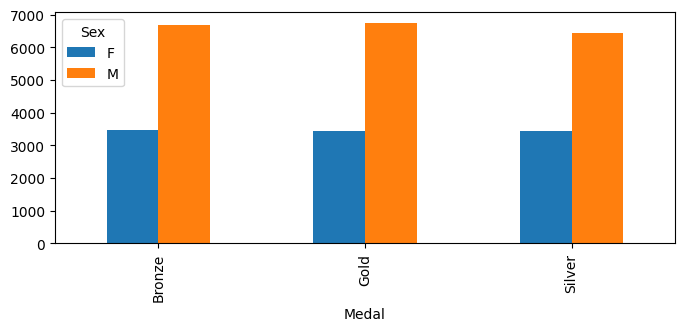

In [96]:
table1.plot(kind="bar", figsize=(8,3))

#### 2. pivot table to check the history of winning trends by male and female over the year

In [85]:
table2 = df[df["Medal"] != 'NA'].groupby(["Year","Sex"]).size().unstack()
table2

Sex,F,M
Year,,
1896,NaN,20.0
1900,NaN,38.0
1904,NaN,59.0
1906,NaN,69.0
1908,NaN,134.0
1912,NaN,130.0
1920,1.0,181.0
1924,4.0,181.0
1928,20.0,150.0


<Axes: xlabel='Year'>

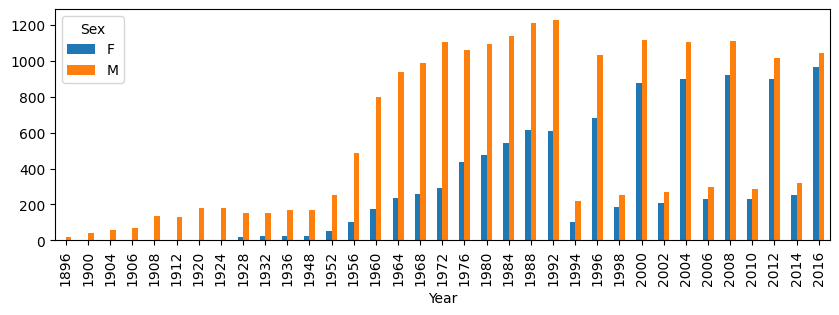

In [102]:
table2.plot(kind="bar", figsize=(10,3))

#### 3. pivot table to check the history of winning diffrent medal trends by male and female over the year

In [104]:
table3 = df[df["Medal"] != 'NA'].groupby(["Year", "Medal", "Sex"]).size().unstack()
table3

Sex              F      M
Year Medal               
1896 Bronze    NaN    3.0
     Gold      NaN   11.0
     Silver    NaN    6.0
1900 Bronze    NaN    9.0
     Gold      NaN   19.0
...            ...    ...
2014 Gold     85.0  105.0
     Silver   82.0  108.0
2016 Bronze  330.0  370.0
     Gold    318.0  343.0
     Silver  319.0  333.0

[105 rows x 2 columns]

<Axes: xlabel='Year,Medal'>

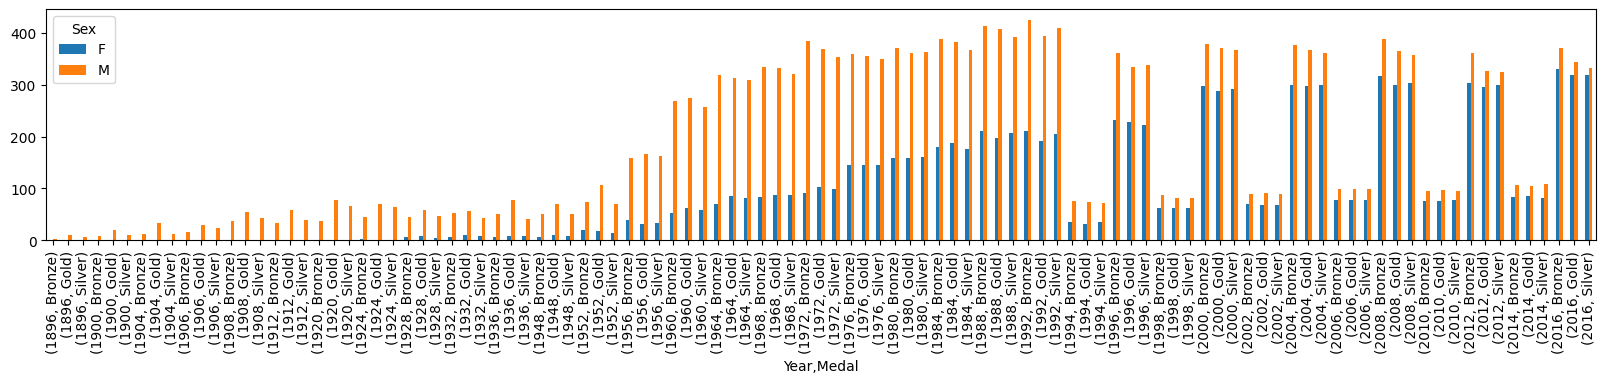

In [106]:
table3.plot(kind="bar", figsize=(20,3))